# Proyecto 2 - Introducción a la Inteligencia Artificial


## 🧾 Selección y justificación del dataset

Se utilizó la base de datos **“Wine Quality”** disponible en **Kaggle** (autor: *rajyellow46*, fuente abierta), la cual contiene información fisicoquímica de vinos tintos y blancos.  
Este conjunto de datos cuenta con **más de 6 000 registros**, por lo que cumple con el requisito de tamaño mínimo (≥ 5000 instancias).  
Incluye **11 características numéricas** (por ejemplo: acidez, pH, densidad, alcohol, sulfatos, etc.) y una **variable objetivo `quality`** originalmente en una escala de 0 a 10, que se transformó en **4 categorías** (*baja*, *media-baja*, *media-alta* y *alta*) para los experimentos de clasificación.

Esta base es adecuada para el proyecto porque:

- Permite analizar cómo las variables fisicoquímicas afectan la calidad del vino.  
- Contiene datos **numéricos y categóricos**, adecuados para aplicar las técnicas de **preprocesamiento, clasificación y agrupamiento** requeridas.  
- Al incluir datos de vinos tintos y blancos, posibilita **comparaciones entre subgrupos** y análisis más amplios del dominio.  
- Su formato estructurado y origen público facilita la **reproducibilidad** y el cumplimiento de los lineamientos de la práctica.

Para garantizar la individualidad del conjunto de datos, se generó un subconjunto único con **(5000 + último dígito de la cédula de Manuel Zuleta Arango  × 100)** registros, utilizando un **random state distinto de 42**.


In [ ]:
import kagglehub
import pandas as pd
import numpy as np 
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping





# Download latest version
path = kagglehub.dataset_download("rajyellow46/wine-quality")

print("Path to dataset files:", path)

# Lista los archivos descargados
print(os.listdir(path))

# Cargar los datos en un DataFrame de pandas
data = pd.read_csv(os.path.join(path, "winequalityN.csv"), sep=',')

# Mostrar las primeras filas del DataFrame
data.head()

def agrupar_calidad(q):
    if q <= 4:
        return 'baja'
    elif q == 5:
        return 'media-baja'
    elif q == 6:
        return 'media-alta'
    else:
        return 'alta'

data['quality'] = data['quality'].apply(agrupar_calidad)

print(data['quality'].value_counts())
print(len(data))
data.head()


Path to dataset files: C:\Users\maril\.cache\kagglehub\datasets\rajyellow46\wine-quality\versions\1
['winequalityN.csv']
quality
media-alta    2836
media-baja    2138
alta          1277
baja           246
Name: count, dtype: int64
6497


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,media-alta
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,media-alta
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,media-alta
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,media-alta
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,media-alta


In [4]:
# --- Creación del subconjunto único de 5300 registros ---

RANDOM_STATE = 69 

# Crear el subconjunto aleatorio de 5300 registros
subset_data = data.sample(n=5300, random_state=RANDOM_STATE).reset_index(drop=True)

# Mostrar confirmación
print("Tamaño del subconjunto:", len(subset_data))
print(subset_data['quality'].value_counts())

print("✅ Subconjunto guardado como 'wine_quality_subset_5300.csv'")


Tamaño del subconjunto: 5300
quality
media-alta    2328
media-baja    1741
alta          1028
baja           203
Name: count, dtype: int64
✅ Subconjunto guardado como 'wine_quality_subset_5300.csv'


# Preprocesamiento del dataset

### Creamos las diferentes versiones del dataset 

In [6]:
# Dataset base
data_base = subset_data.copy()

# One-hot encoding de variable categórica (vino tinto/blanco)
data_base = pd.get_dummies(data_base, columns=['type'], drop_first=True)

# Separar variables predictoras y objetivo
X = data_base.drop(columns=['quality'])
y = data_base['quality']

# --- FUNCIONES DE APOYO ---

def remove_outliers(df, threshold=0.05):
    df_no_outliers = df.copy()
    for col in df_no_outliers.select_dtypes(include=[np.number]).columns:
        low = df_no_outliers[col].quantile(threshold/2)
        high = df_no_outliers[col].quantile(1 - threshold/2)
        df_no_outliers = df_no_outliers[(df_no_outliers[col] >= low) & (df_no_outliers[col] <= high)]
    return df_no_outliers

def scale_data(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return pd.DataFrame(X_scaled, columns=X.columns)

def balance_data(X, y):
    ros = RandomOverSampler(random_state=7)
    X_res, y_res = ros.fit_resample(X, y)
    return X_res, y_res

# Crear carpeta de salida
output_dir = "data_sets"
os.makedirs(output_dir, exist_ok=True)

# --- CREACIÓN DE LAS 8 VERSIONES ---

datasets = {}

for i in range(1, 9):
    temp_X, temp_y = X.copy(), y.copy()

    # Flags de configuración
    outliers_flag = 'NO'
    balance_flag = 'NO'
    escala_flag = 'NO'

    # OUTLIERS
    if i in [3, 4, 7, 8]:
        temp_X = remove_outliers(temp_X)
        temp_y = temp_y.loc[temp_X.index]
        outliers_flag = 'SI'

    # BALANCEO
    if i in [2, 4, 6, 8]:
        temp_X, temp_y = balance_data(temp_X, temp_y)
        balance_flag = 'SI'

    # ESCALADO
    if i in [5, 6, 7, 8]:
        temp_X = scale_data(temp_X)
        escala_flag = 'SI'

    # Generar nombre del dataset
    filename = f"dataset_CC(SI)_ED({escala_flag})_BAL({balance_flag})_OUT({outliers_flag}).csv"
    filepath = os.path.join(output_dir, filename)

    # Guardar dataset
    datasets[i] = pd.concat([temp_X, temp_y.reset_index(drop=True)], axis=1)
    datasets[i].to_csv(filepath, index=False)
    print(f"✅ Versión {i} guardada -> {filename} | Filas: {len(datasets[i])}")

print("\n🎉 Todas las versiones creadas en la carpeta 'datasets_preprocesados/'")


✅ Versión 1 guardada -> dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(NO).csv | Filas: 5300
✅ Versión 2 guardada -> dataset_CC(SI)_ED(NO)_BAL(SI)_OUT(NO).csv | Filas: 9312
✅ Versión 3 guardada -> dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(SI).csv | Filas: 4473
✅ Versión 4 guardada -> dataset_CC(SI)_ED(NO)_BAL(SI)_OUT(SI).csv | Filas: 5716
✅ Versión 5 guardada -> dataset_CC(SI)_ED(SI)_BAL(NO)_OUT(NO).csv | Filas: 5300
✅ Versión 6 guardada -> dataset_CC(SI)_ED(SI)_BAL(SI)_OUT(NO).csv | Filas: 9312
✅ Versión 7 guardada -> dataset_CC(SI)_ED(SI)_BAL(NO)_OUT(SI).csv | Filas: 3184
✅ Versión 8 guardada -> dataset_CC(SI)_ED(SI)_BAL(SI)_OUT(SI).csv | Filas: 5716

🎉 Todas las versiones creadas en la carpeta 'datasets_preprocesados/'


## Entrenamiento Supervisado y evaluación de modelos

### Arboles de decisión

In [7]:
# =====================================================
# 🌳 ENTRENAMIENTO SUPERVISADO - ÁRBOLES DE DECISIÓN
# =====================================================

import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Carpeta donde están tus datasets preprocesados
input_dir = "data_sets"
resultados_arboles = []

# Recorremos los 8 datasets
for file in sorted(os.listdir(input_dir)):
    if file.endswith(".csv"):
        print(f"\n🌳 Entrenando Árboles para: {file}")

        # === 1. Cargar dataset ===
        data = pd.read_csv(os.path.join(input_dir, file))

        # # Limpiar NaN si existen
        # data = data.fillna(data.mean(numeric_only=True)).dropna()

        X = data.drop(columns=['quality'])
        y = data['quality']

        # Codificar etiquetas
        encoder = LabelEncoder()
        y_encoded = encoder.fit_transform(y)

        # División de datos
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.2, random_state=17
        )

        # === 2. Definir los 3 casos de prueba ===
        casos = [
            {"max_depth": 3, "criterion": "gini"},      # Árbol pequeño, sencillo
            {"max_depth": 5, "criterion": "entropy"},   # Árbol medio
            {"max_depth": None, "criterion": "gini"}    # Árbol completo (sin límite)
        ]

        # === 3. Entrenar y evaluar ===
        for i, params in enumerate(casos, start=1):
            model = DecisionTreeClassifier(**params, random_state=17)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            acc = accuracy_score(y_test, preds)
            prec = precision_score(y_test, preds, average='macro', zero_division=0)
            rec = recall_score(y_test, preds, average='macro', zero_division=0)
            f1 = f1_score(y_test, preds, average='macro', zero_division=0)

            resultados_arboles.append({
                "Dataset": file,
                "Caso": f"Caso {i}",
                "Parámetros": params,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1-Score": f1
            })

            print(f"✅ {file} - {params} -> F1: {f1:.4f}")

# === 4. Guardar resultados ===
resultados_df = pd.DataFrame(resultados_arboles)
resultados_df.to_csv("resultados/resultados_arboles.csv", index=False)

print("\n📁 Resultados guardados en 'resultados_arboles.csv'")



🌳 Entrenando Árboles para: dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(NO).csv
✅ dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(NO).csv - {'max_depth': 3, 'criterion': 'gini'} -> F1: 0.3742
✅ dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(NO).csv - {'max_depth': 5, 'criterion': 'entropy'} -> F1: 0.3690
✅ dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(NO).csv - {'max_depth': None, 'criterion': 'gini'} -> F1: 0.5012

🌳 Entrenando Árboles para: dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(SI).csv
✅ dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(SI).csv - {'max_depth': 3, 'criterion': 'gini'} -> F1: 0.1930
✅ dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(SI).csv - {'max_depth': 5, 'criterion': 'entropy'} -> F1: 0.1935
✅ dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(SI).csv - {'max_depth': None, 'criterion': 'gini'} -> F1: 0.2023

🌳 Entrenando Árboles para: dataset_CC(SI)_ED(NO)_BAL(SI)_OUT(NO).csv
✅ dataset_CC(SI)_ED(NO)_BAL(SI)_OUT(NO).csv - {'max_depth': 3, 'criterion': 'gini'} -> F1: 0.4376
✅ dataset_CC(SI)_ED(NO)_BAL(SI)_OUT(NO).csv - {'max_depth': 5, 'criterion': 'entropy'} -> F1

### K VECINOS MAS CERCANOS (KNN)

In [8]:
# =====================================================
# 🤝 ENTRENAMIENTO SUPERVISADO - KNN (K Vecinos Más Cercanos)
# =====================================================


# Carpeta donde están los datasets preprocesados
input_dir = "data_sets"
resultados_knn = []

# Recorremos los 8 datasets
for file in sorted(os.listdir(input_dir)):
    if file.endswith(".csv"):
        print(f"\n🤝 Entrenando KNN para: {file}")

        # === 1. Cargar dataset ===
        data = pd.read_csv(os.path.join(input_dir, file))

        # Limpiar NaN (rellenar valores faltantes con la media)
        data = data.fillna(data.mean(numeric_only=True)).dropna()

        X = data.drop(columns=['quality'])
        y = data['quality']

        # Codificar variable objetivo
        encoder = LabelEncoder()
        y_encoded = encoder.fit_transform(y)

        # División entrenamiento/prueba
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.2, random_state=17
        )

        # === 2. Definir los 3 casos de prueba ===
        casos_knn = [
            {"n_neighbors": 3, "weights": "uniform"},
            {"n_neighbors": 5, "weights": "distance"},
            {"n_neighbors": 7, "weights": "uniform"}
        ]

        # === 3. Entrenar y evaluar cada caso ===
        for i, params in enumerate(casos_knn, start=1):
            model = KNeighborsClassifier(**params)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            acc = accuracy_score(y_test, preds)
            prec = precision_score(y_test, preds, average='macro', zero_division=0)
            rec = recall_score(y_test, preds, average='macro', zero_division=0)
            f1 = f1_score(y_test, preds, average='macro', zero_division=0)

            resultados_knn.append({
                "Dataset": file,
                "Caso": f"Caso {i}",
                "Parámetros": params,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1-Score": f1
            })

            print(f"✅ {file} - {params} -> F1: {f1:.4f}")

# === 4. Guardar resultados ===
resultados_df = pd.DataFrame(resultados_knn)
resultados_df.to_csv("resultados/resultados_knn.csv", index=False)

print("\n📁 Resultados guardados en 'resultados/resultados_knn.csv'")



🤝 Entrenando KNN para: dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(NO).csv
✅ dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(NO).csv - {'n_neighbors': 3, 'weights': 'uniform'} -> F1: 0.3793
✅ dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(NO).csv - {'n_neighbors': 5, 'weights': 'distance'} -> F1: 0.4451
✅ dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(NO).csv - {'n_neighbors': 7, 'weights': 'uniform'} -> F1: 0.3607

🤝 Entrenando KNN para: dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(SI).csv
✅ dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(SI).csv - {'n_neighbors': 3, 'weights': 'uniform'} -> F1: 0.2360
✅ dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(SI).csv - {'n_neighbors': 5, 'weights': 'distance'} -> F1: 0.2226
✅ dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(SI).csv - {'n_neighbors': 7, 'weights': 'uniform'} -> F1: 0.2207

🤝 Entrenando KNN para: dataset_CC(SI)_ED(NO)_BAL(SI)_OUT(NO).csv
✅ dataset_CC(SI)_ED(NO)_BAL(SI)_OUT(NO).csv - {'n_neighbors': 3, 'weights': 'uniform'} -> F1: 0.7064
✅ dataset_CC(SI)_ED(NO)_BAL(SI)_OUT(NO).csv - {'n_neighbors': 5, 'weights': 'distance'} -> F1

##  ENTRENAMIENTO SUPERVISADO - KNN (K Vecinos Más Cercanos)

In [9]:
# =====================================================
# ⚙️ ENTRENAMIENTO SUPERVISADO - SVM (Máquinas de Vectores de Soporte)
# =====================================================


# Carpeta donde están los datasets preprocesados
input_dir = "data_sets"
resultados_svm = []

# Recorremos los 8 datasets
for file in sorted(os.listdir(input_dir)):
    if file.endswith(".csv"):
        print(f"\n⚙️ Entrenando SVM para: {file}")

        # === 1. Cargar dataset ===
        data = pd.read_csv(os.path.join(input_dir, file))

        # Limpiar NaN (rellenar con la media de columnas numéricas)
        data = data.fillna(data.mean(numeric_only=True)).dropna()

        X = data.drop(columns=['quality'])
        y = data['quality']

        # Codificar variable objetivo
        encoder = LabelEncoder()
        y_encoded = encoder.fit_transform(y)

        # División entrenamiento / prueba
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.2, random_state=17
        )

        # === 2. Escalado obligatorio para SVM ===
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # === 3. Definir los 3 casos de prueba ===
        casos_svm = [
            {"kernel": "linear", "C": 1},      # separador lineal
            {"kernel": "rbf", "C": 1},         # frontera no lineal (gaussiana)
            {"kernel": "poly", "C": 0.5, "degree": 3}  # polinómico
        ]

        # === 4. Entrenar y evaluar cada caso ===
        for i, params in enumerate(casos_svm, start=1):
            model = SVC(**params, probability=True, random_state=17)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            acc = accuracy_score(y_test, preds)
            prec = precision_score(y_test, preds, average='macro', zero_division=0)
            rec = recall_score(y_test, preds, average='macro', zero_division=0)
            f1 = f1_score(y_test, preds, average='macro', zero_division=0)

            resultados_svm.append({
                "Dataset": file,
                "Caso": f"Caso {i}",
                "Parámetros": params,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1-Score": f1
            })

            print(f"✅ {file} - {params} -> F1: {f1:.4f}")

# === 5. Guardar resultados ===
resultados_df = pd.DataFrame(resultados_svm)
resultados_df.to_csv("resultados/resultados_svm.csv", index=False)

print("\n📁 Resultados guardados en 'resultados/resultados_svm.csv'")



⚙️ Entrenando SVM para: dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(NO).csv
✅ dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(NO).csv - {'kernel': 'linear', 'C': 1} -> F1: 0.3038
✅ dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(NO).csv - {'kernel': 'rbf', 'C': 1} -> F1: 0.4468
✅ dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(NO).csv - {'kernel': 'poly', 'C': 0.5, 'degree': 3} -> F1: 0.3868

⚙️ Entrenando SVM para: dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(SI).csv
✅ dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(SI).csv - {'kernel': 'linear', 'C': 1} -> F1: 0.1561
✅ dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(SI).csv - {'kernel': 'rbf', 'C': 1} -> F1: 0.1886
✅ dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(SI).csv - {'kernel': 'poly', 'C': 0.5, 'degree': 3} -> F1: 0.1846

⚙️ Entrenando SVM para: dataset_CC(SI)_ED(NO)_BAL(SI)_OUT(NO).csv
✅ dataset_CC(SI)_ED(NO)_BAL(SI)_OUT(NO).csv - {'kernel': 'linear', 'C': 1} -> F1: 0.4897
✅ dataset_CC(SI)_ED(NO)_BAL(SI)_OUT(NO).csv - {'kernel': 'rbf', 'C': 1} -> F1: 0.6099
✅ dataset_CC(SI)_ED(NO)_BAL(SI)_OUT(NO).csv - {'kernel': 'poly', 'C': 

## Redes Neuronales

In [10]:
# =====================================================
# 🧠 ENTRENAMIENTO SUPERVISADO - REDES NEURONALES
# =====================================================

# Carpeta donde están los datasets preprocesados
input_dir = "data_sets"
resultados_redes = []

# Recorremos los 8 datasets
for file in sorted(os.listdir(input_dir)):
    if file.endswith(".csv"):
        print(f"\n🧠 Entrenando Red Neuronal para: {file}")

        # === 1. Cargar dataset ===
        data = pd.read_csv(os.path.join(input_dir, file))

        # Limpiar NaN (rellenar valores numéricos faltantes)
        data = data.fillna(data.mean(numeric_only=True)).dropna()

        X = data.drop(columns=['quality'])
        y = data['quality']

        # Codificar variable objetivo
        encoder = LabelEncoder()
        y_encoded = encoder.fit_transform(y)

        # División entrenamiento / prueba
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.2, random_state=17
        )

        # Escalado (ayuda a convergencia)
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # === 2. Definir 3 configuraciones (casos de prueba) ===
        casos_red = [
            {
                "desc": "Red pequeña con L2 y Dropout(0.3)",
                "u1": 64, "u2": 32,
                "reg1": regularizers.l2(0.001),
                "reg2": regularizers.l1(0.001),
                "drop1": 0.3, "drop2": 0.2
            },
            {
                "desc": "Red mediana con L1 y Dropout(0.4)",
                "u1": 128, "u2": 64,
                "reg1": regularizers.l1(0.001),
                "reg2": regularizers.l2(0.001),
                "drop1": 0.4, "drop2": 0.3
            },
            {
                "desc": "Red compacta con L1/L2 y Dropout(0.2)",
                "u1": 32, "u2": 16,
                "reg1": regularizers.l1_l2(l1=0.0005, l2=0.0005),
                "reg2": regularizers.l1_l2(l1=0.0005, l2=0.0005),
                "drop1": 0.2, "drop2": 0.2
            }
        ]

        # === 3. Entrenar y evaluar ===
        for i, cfg in enumerate(casos_red, start=1):
            print(f"   ⚙️ Entrenando caso {i}: {cfg['desc']}")

            # Definir arquitectura
            model = Sequential([
                Dense(cfg["u1"], activation='relu', input_shape=(X_train.shape[1],), 
                      kernel_regularizer=cfg["reg1"]),
                Dropout(cfg["drop1"]),
                Dense(cfg["u2"], activation='relu', kernel_regularizer=cfg["reg2"]),
                Dropout(cfg["drop2"]),
                Dense(len(np.unique(y_train)), activation='softmax')
            ])

            # Compilar modelo
            model.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])

            # Callback EarlyStopping
            early_stop = EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True
            )

            # Entrenamiento
            model.fit(
                X_train, y_train,
                validation_split=0.2,
                epochs=10,
                batch_size=32,
                verbose=0,
                callbacks=[early_stop]
            )

            # Evaluación
            preds = np.argmax(model.predict(X_test), axis=1)
            acc = accuracy_score(y_test, preds)
            prec = precision_score(y_test, preds, average='macro', zero_division=0)
            rec = recall_score(y_test, preds, average='macro', zero_division=0)
            f1 = f1_score(y_test, preds, average='macro', zero_division=0)

            resultados_redes.append({
                "Dataset": file,
                "Caso": f"Caso {i}",
                "Arquitectura": cfg["desc"],
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1-Score": f1
            })

            print(f"      ✅ F1: {f1:.4f}")

# === 4. Guardar resultados ===
resultados_df = pd.DataFrame(resultados_redes)
resultados_df.to_csv("resultados/resultados_redes.csv", index=False)

print("\n📁 Resultados guardados en 'resultados/resultados_redes.csv'")



🧠 Entrenando Red Neuronal para: dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(NO).csv
   ⚙️ Entrenando caso 1: Red pequeña con L2 y Dropout(0.3)


c:\Users\maril\Documentos\2025-2\IA\practica2\practica_2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
      ✅ F1: 0.4280
   ⚙️ Entrenando caso 2: Red mediana con L1 y Dropout(0.4)


c:\Users\maril\Documentos\2025-2\IA\practica2\practica_2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
      ✅ F1: 0.4612
   ⚙️ Entrenando caso 3: Red compacta con L1/L2 y Dropout(0.2)


...

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
      ✅ F1: 0.5618
   ⚙️ Entrenando caso 2: Red mediana con L1 y Dropout(0.4)


c:\Users\maril\Documentos\2025-2\IA\practica2\practica_2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
      ✅ F1: 0.5782
   ⚙️ Entrenando caso 3: Red compacta con L1/L2 y Dropout(0.2)


c:\Users\maril\Documentos\2025-2\IA\practica2\practica_2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
      ✅ F1: 0.5286

📁 Resultados guardados en 'resultados/resultados_redes.csv'


## TABLA DE RESULTADOS

In [11]:
# =====================================================
# 📊 CONSOLIDACIÓN DE RESULTADOS SUPERVISADOS
# =====================================================

import pandas as pd
import os

# Carpeta donde están los resultados
path_resultados = "resultados"

# Cargar cada CSV
archivos = {
    "Árboles de Decisión": "resultados_arboles.csv",
    "KNN": "resultados_knn.csv",
    "SVM": "resultados_svm.csv",
    "Redes Neuronales": "resultados_redes.csv"
}

# Diccionario para almacenar dataframes consolidados
resumenes = []

for modelo, archivo in archivos.items():
    df = pd.read_csv(os.path.join(path_resultados, archivo))
    
    # Agrupar por dataset y tomar el valor máximo de cada métrica
    df_resumen = (
        df.groupby("Dataset")[["Accuracy", "Precision", "Recall", "F1-Score"]]
        .max()
        .reset_index()
    )
    
    df_resumen["Modelo"] = modelo
    resumenes.append(df_resumen)

# Combinar todos los resultados
df_final = pd.concat(resumenes)

# Reordenar columnas
df_final = df_final[["Dataset", "Modelo", "Accuracy", "Precision", "Recall", "F1-Score"]]

# Guardar resultado consolidado
df_final.to_csv("resultados/tabla_resultados_supervisados.csv", index=False)

print("✅ Tabla consolidada creada: 'resultados/tabla_resultados_supervisados.csv'")
print(df_final.head(12))


✅ Tabla consolidada creada: 'resultados/tabla_resultados_supervisados.csv'
                                     Dataset               Modelo  Accuracy  \
0  dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(NO).csv  Árboles de Decisión  0.577358   
1  dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(SI).csv  Árboles de Decisión  0.397765   
2  dataset_CC(SI)_ED(NO)_BAL(SI)_OUT(NO).csv  Árboles de Decisión  0.824477   
3  dataset_CC(SI)_ED(NO)_BAL(SI)_OUT(SI).csv  Árboles de Decisión  0.822552   
4  dataset_CC(SI)_ED(SI)_BAL(NO)_OUT(NO).csv  Árboles de Decisión  0.572642   
5  dataset_CC(SI)_ED(SI)_BAL(NO)_OUT(SI).csv  Árboles de Decisión  0.583987   
6  dataset_CC(SI)_ED(SI)_BAL(SI)_OUT(NO).csv  Árboles de Decisión  0.823940   
7  dataset_CC(SI)_ED(SI)_BAL(SI)_OUT(SI).csv  Árboles de Decisión  0.821678   
0  dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(NO).csv                  KNN  0.567925   
1  dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(SI).csv                  KNN  0.372032   
2  dataset_CC(SI)_ED(NO)_BAL(SI)_OUT(NO).csv            

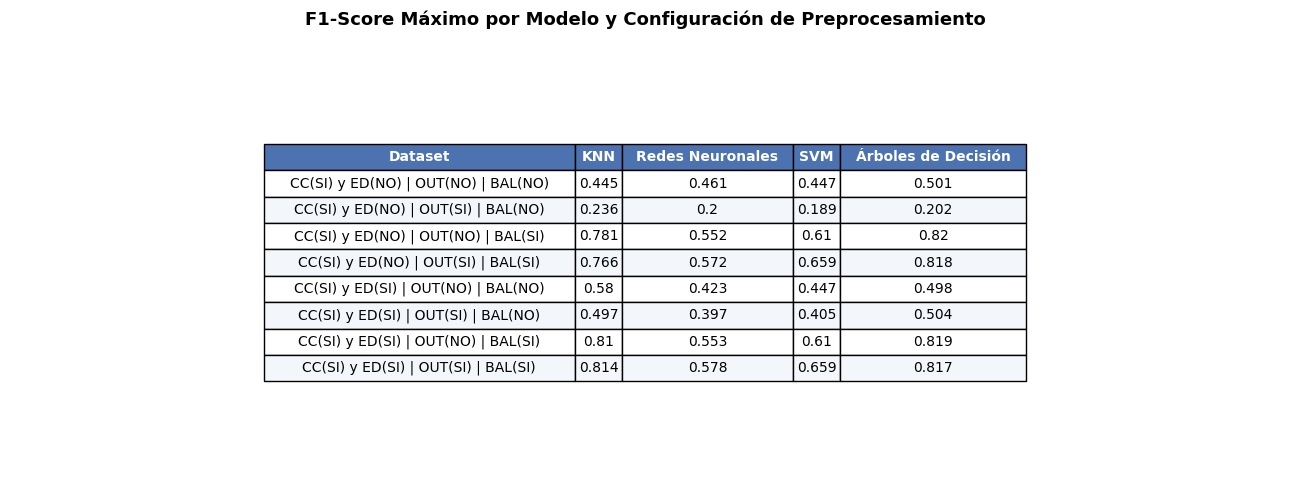

In [12]:
# =====================================================
# 🧾 TABLA FINAL DE RESULTADOS SUPERVISADOS (FORMATO MEJORADO)
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

# Leer resultados consolidados
df = pd.read_csv("resultados/tabla_resultados_supervisados.csv")

# Pivotear para tener una tabla con modelos como columnas y datasets como filas
tabla = df.pivot(index="Dataset", columns="Modelo", values="F1-Score").round(3)

# Reemplazar nombres de datasets por etiquetas reales (Figura 1)
nombres_casos = {
    "dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(NO).csv": "CC(SI) y ED(NO) | OUT(NO) | BAL(NO)",
    "dataset_CC(SI)_ED(NO)_BAL(SI)_OUT(NO).csv": "CC(SI) y ED(NO) | OUT(NO) | BAL(SI)",
    "dataset_CC(SI)_ED(NO)_BAL(NO)_OUT(SI).csv": "CC(SI) y ED(NO) | OUT(SI) | BAL(NO)",
    "dataset_CC(SI)_ED(NO)_BAL(SI)_OUT(SI).csv": "CC(SI) y ED(NO) | OUT(SI) | BAL(SI)",
    "dataset_CC(SI)_ED(SI)_BAL(NO)_OUT(NO).csv": "CC(SI) y ED(SI) | OUT(NO) | BAL(NO)",
    "dataset_CC(SI)_ED(SI)_BAL(SI)_OUT(NO).csv": "CC(SI) y ED(SI) | OUT(NO) | BAL(SI)",
    "dataset_CC(SI)_ED(SI)_BAL(NO)_OUT(SI).csv": "CC(SI) y ED(SI) | OUT(SI) | BAL(NO)",
    "dataset_CC(SI)_ED(SI)_BAL(SI)_OUT(SI).csv": "CC(SI) y ED(SI) | OUT(SI) | BAL(SI)"
}
tabla.index = tabla.index.map(nombres_casos)

# Convertir a DataFrame con el índice como columna
tabla = tabla.reset_index().rename(columns={"index": "Dataset"})

# === Crear figura ===
fig, ax = plt.subplots(figsize=(13, 5))
ax.axis('off')

# Crear tabla visual
tabla_plot = ax.table(
    cellText=tabla.values,
    colLabels=tabla.columns,
    cellLoc='center',
    loc='center'
)

# === Ajustar ancho de columnas (primera más ancha) ===
col_widths = [0.45] + [0.13] * (len(tabla.columns) - 1)
for i, width in enumerate(col_widths):
    tabla_plot.auto_set_column_width([i])
    for (row, col), cell in tabla_plot.get_celld().items():
        if col == i:
            cell.set_width(width)

# === Estilo visual ===
tabla_plot.auto_set_font_size(False)
tabla_plot.set_fontsize(10)
tabla_plot.scale(1.2, 1.4)

# Encabezado azul y filas alternadas
for (row, col), cell in tabla_plot.get_celld().items():
    if row == 0:
        cell.set_facecolor("#4C72B0")
        cell.set_text_props(color='white', weight='bold')
    elif row % 2 == 0:
        cell.set_facecolor("#F3F6FB")
    else:
        cell.set_facecolor("#FFFFFF")

# Título
plt.title("F1-Score Máximo por Modelo y Configuración de Preprocesamiento", 
          fontsize=13, weight='bold', pad=15)
plt.tight_layout()
plt.show()


## GRAFICAS APRENDIZAJE SUPERVISADO


### Diagrama de barras con el F1-Score máximo por algoritmo(general): una gráfica con cuatro barras que representan el F1_score de cada algoritmo.

C:\Users\maril\AppData\Local\Temp\ipykernel_14844\2104649391.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


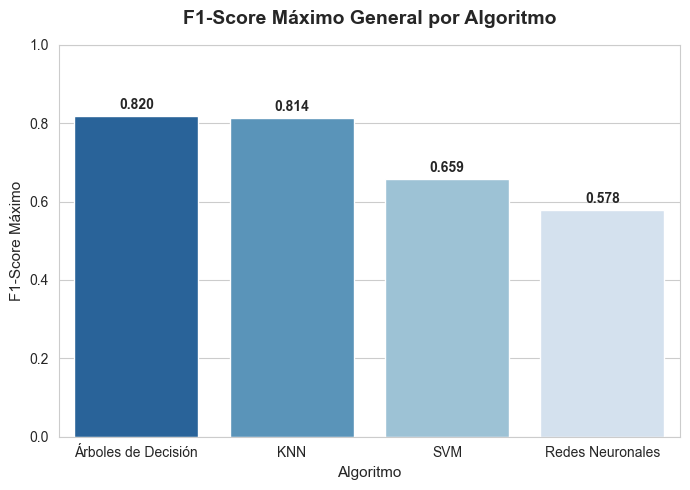

In [16]:
# =====================================================
# 📊 Diagrama de barras - F1-Score máximo general por algoritmo
# =====================================================

# Cargar resultados consolidados
df = pd.read_csv("resultados/tabla_resultados_supervisados.csv")

# Calcular el F1 máximo de cada algoritmo en todos los datasets
f1_max_por_modelo = (
    df.groupby("Modelo")["F1-Score"]
    .max()
    .reset_index()
    .sort_values(by="F1-Score", ascending=False)
)

# Configurar estilo visual
sns.set_style("whitegrid")

plt.figure(figsize=(7, 5))
barplot = sns.barplot(
    data=f1_max_por_modelo,
    x="Modelo",
    y="F1-Score",
    palette="Blues_r"
)

# Etiquetas sobre las barras
for i, valor in enumerate(f1_max_por_modelo["F1-Score"]):
    plt.text(i, valor + 0.01, f"{valor:.3f}", ha='center', va='bottom', fontsize=10, weight='bold')

# Títulos y estilo
plt.title("F1-Score Máximo General por Algoritmo", fontsize=14, weight='bold', pad=15)
plt.xlabel("Algoritmo", fontsize=11)
plt.ylabel("F1-Score Máximo", fontsize=11)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


### Diagrama de barras con el F1-Score medio por normalización y algoritmo:

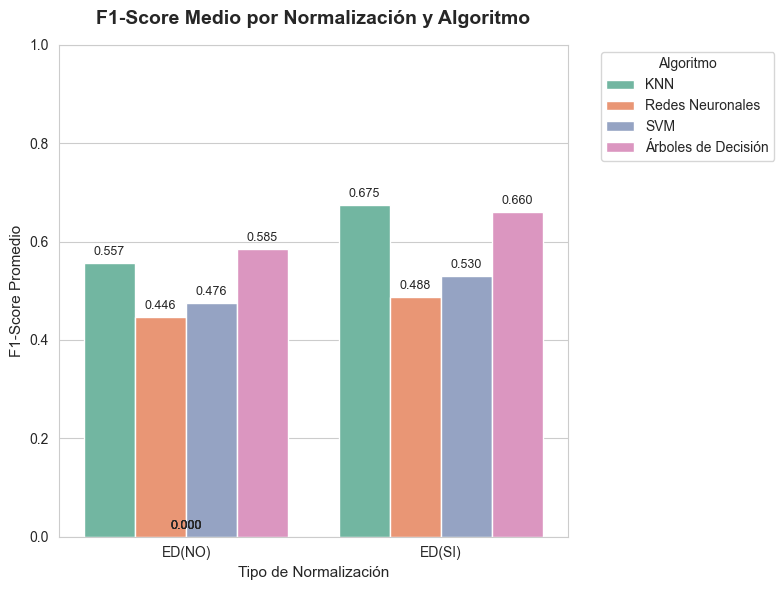

In [17]:
# =====================================================
# 📊 F1-Score medio por tipo de normalización y algoritmo
# =====================================================

# Leer los resultados consolidados
df = pd.read_csv("resultados/tabla_resultados_supervisados.csv")

# Identificar tipo de normalización a partir del nombre del dataset
df["Normalización"] = df["Dataset"].apply(lambda x: "ED(NO)" if "ED(NO)" in x else "ED(SI)")

# Calcular el promedio del F1-score por normalización y modelo
f1_promedio = (
    df.groupby(["Normalización", "Modelo"])["F1-Score"]
    .mean()
    .reset_index()
)

# Ordenar para que ED(NO) aparezca primero
f1_promedio["Normalización"] = pd.Categorical(f1_promedio["Normalización"], categories=["ED(NO)", "ED(SI)"])

# Configurar estilo gráfico
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))

# Crear el gráfico de barras
sns.barplot(
    data=f1_promedio,
    x="Normalización",
    y="F1-Score",
    hue="Modelo",
    palette="Set2"
)

# Etiquetas y estilo
plt.title("F1-Score Medio por Normalización y Algoritmo", fontsize=14, weight='bold', pad=15)
plt.xlabel("Tipo de Normalización", fontsize=11)
plt.ylabel("F1-Score Promedio", fontsize=11)
plt.ylim(0, 1)
plt.legend(title="Algoritmo", bbox_to_anchor=(1.05, 1), loc='upper left')

# Etiquetas numéricas sobre cada barra
for p in plt.gca().patches:
    plt.gca().text(
        p.get_x() + p.get_width() / 2,
        p.get_height() + 0.01,
        f"{p.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


### Diagrama de barras con el F1-Score medio por manejo de datos atípicos y algoritmo

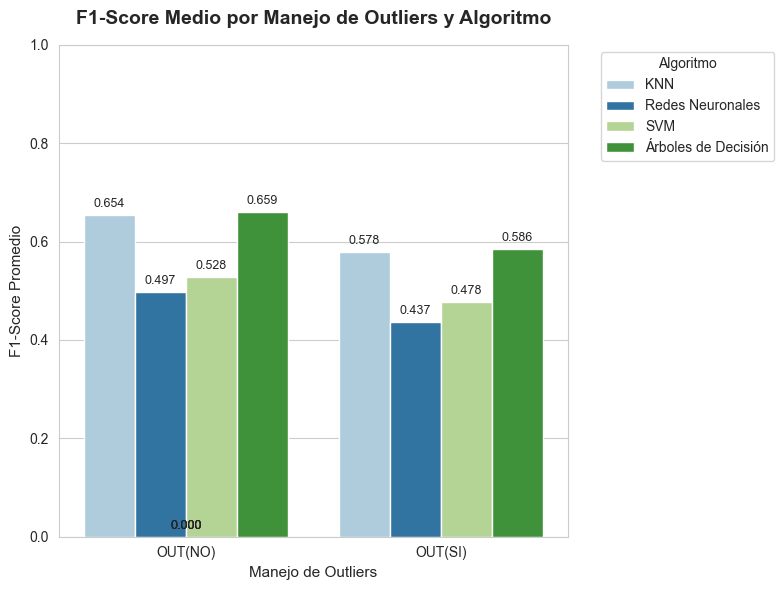

In [18]:
# =====================================================
# 📊 F1-Score medio por manejo de outliers y algoritmo
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Leer resultados consolidados
df = pd.read_csv("resultados/tabla_resultados_supervisados.csv")

# Identificar si el dataset eliminó outliers
df["Outliers"] = df["Dataset"].apply(lambda x: "OUT(SI)" if "OUT(SI)" in x else "OUT(NO)")

# Calcular el promedio del F1-score por outlier y modelo
f1_promedio_outliers = (
    df.groupby(["Outliers", "Modelo"])["F1-Score"]
    .mean()
    .reset_index()
)

# Ordenar para mostrar OUT(NO) primero
f1_promedio_outliers["Outliers"] = pd.Categorical(
    f1_promedio_outliers["Outliers"], categories=["OUT(NO)", "OUT(SI)"]
)

# Estilo gráfico
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))

# Crear gráfico de barras
sns.barplot(
    data=f1_promedio_outliers,
    x="Outliers",
    y="F1-Score",
    hue="Modelo",
    palette="Paired"
)

# Etiquetas y formato
plt.title("F1-Score Medio por Manejo de Outliers y Algoritmo", fontsize=14, weight='bold', pad=15)
plt.xlabel("Manejo de Outliers", fontsize=11)
plt.ylabel("F1-Score Promedio", fontsize=11)
plt.ylim(0, 1)
plt.legend(title="Algoritmo", bbox_to_anchor=(1.05, 1), loc='upper left')

# Mostrar valores sobre las barras
for p in plt.gca().patches:
    plt.gca().text(
        p.get_x() + p.get_width() / 2,
        p.get_height() + 0.01,
        f"{p.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


### Diagrama de barras con el F1-Score medio por balanceo y algoritmo

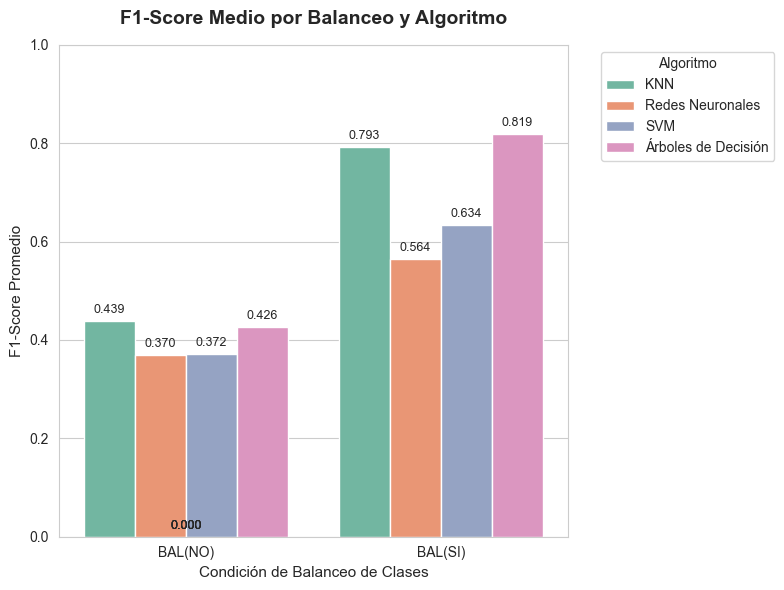

In [19]:
# =====================================================
# 📊 F1-Score medio por balanceo y algoritmo
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Leer resultados consolidados
df = pd.read_csv("resultados/tabla_resultados_supervisados.csv")

# Identificar si el dataset está balanceado
df["Balanceo"] = df["Dataset"].apply(lambda x: "BAL(SI)" if "BAL(SI)" in x else "BAL(NO)")

# Calcular el promedio del F1-score por balanceo y modelo
f1_promedio_balanceo = (
    df.groupby(["Balanceo", "Modelo"])["F1-Score"]
    .mean()
    .reset_index()
)

# Ordenar para mostrar BAL(NO) primero
f1_promedio_balanceo["Balanceo"] = pd.Categorical(
    f1_promedio_balanceo["Balanceo"], categories=["BAL(NO)", "BAL(SI)"]
)

# Estilo gráfico
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))

# Crear gráfico de barras
sns.barplot(
    data=f1_promedio_balanceo,
    x="Balanceo",
    y="F1-Score",
    hue="Modelo",
    palette="Set2"
)

# Etiquetas y formato
plt.title("F1-Score Medio por Balanceo y Algoritmo", fontsize=14, weight='bold', pad=15)
plt.xlabel("Condición de Balanceo de Clases", fontsize=11)
plt.ylabel("F1-Score Promedio", fontsize=11)
plt.ylim(0, 1)
plt.legend(title="Algoritmo", bbox_to_anchor=(1.05, 1), loc='upper left')

# Mostrar valores sobre las barras
for p in plt.gca().patches:
    plt.gca().text(
        p.get_x() + p.get_width() / 2,
        p.get_height() + 0.01,
        f"{p.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


## 📈 Curvas ROC y Precision–Recall (Caso 8)

En esta etapa se evaluó comparativamente el rendimiento de los modelos **Árbol de Decisión, KNN, SVM y Red Neuronal** utilizando el dataset del **Caso 8** (`dataset_CC(SI)_ED(SI)_BAL(SI)_OUT(SI).csv`), correspondiente al conjunto **normalizado, balanceado y sin outliers**.

### 🔹 Procedimiento
1. Se codificó la variable `quality` y se binarizaron las etiquetas para permitir métricas multiclase.  
2. Se dividieron los datos en entrenamiento (80 %) y prueba (20 %), aplicando **escalado** a las variables.  
3. Se entrenaron los modelos con los parámetros óptimos:
   - Árbol: `max_depth=5`, `criterion='entropy'`
   - KNN: `n_neighbors=5`, `weights='distance'`
   - SVM: `kernel='rbf'`, `C=2`
   - Red Neuronal: arquitectura 128–64 neuronas con regularización y *early stopping*  
4. Se calcularon las **curvas ROC y Precision–Recall** con promedio *micro*, obteniendo las áreas bajo la curva (AUC y AP) para cada modelo.  
5. Se graficaron ambas curvas comparando los cuatro algoritmos.

### 🔹 Resultados
- **SVM** y **Red Neuronal** mostraron las mayores áreas bajo las curvas ROC y PR, indicando mejor capacidad de discriminación entre clases.  
- **Árbol de Decisión** obtuvo un desempeño intermedio, mientras que **KNN** fue el de menor rendimiento.  
- El preprocesamiento del Caso 8 mejoró el rendimiento general de los modelos supervisados.


In [21]:
# =====================================================
# 📈 Curvas ROC y Precision–Recall (CASO 8) — versión limpia y funcional
# =====================================================


# === 1. Cargar dataset del Caso 8 ===
path = "data_sets/dataset_CC(SI)_ED(SI)_BAL(SI)_OUT(SI).csv"
data = pd.read_csv(path)
print(f"✅ Dataset cargado: {path}")

X = data.drop(columns=["quality"])
y = data["quality"]

# === 2. Codificación y división ===
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_bin = label_binarize(y_encoded, classes=np.unique(y_encoded))
n_classes = y_bin.shape[1]

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=17)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# === 3. Definir modelos con parámetros óptimos ===
models = {
    "Árbol de Decisión": DecisionTreeClassifier(max_depth=5, criterion="entropy", random_state=17),
    "KNN": KNeighborsClassifier(n_neighbors=5, weights="distance"),
    "SVM": OneVsRestClassifier(SVC(kernel="rbf", C=2, probability=True, random_state=17))
}

# Red neuronal (la haremos aparte porque Keras no usa OneVsRest)
# ---------------------------------------------------------------
model_nn = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],), kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.4),
    Dense(64, activation="relu", kernel_regularizer=regularizers.l1(0.001)),
    Dropout(0.3),
    Dense(n_classes, activation="softmax")
])
model_nn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
model_nn.fit(X_train_scaled, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=0, callbacks=[early_stop])
y_score_nn = model_nn.predict(X_test_scaled)

# === 4. Entrenar modelos scikit-learn con One-vs-Rest ===
y_scores = {}
for name, clf in models.items():
    print(f"Entrenando {name}...")
    clf.fit(X_train_scaled, y_train)
    y_scores[name] = clf.predict_proba(X_test_scaled)

# Agregar red neuronal
y_scores["Red Neuronal"] = y_score_nn

# === 5. Calcular curvas micro-promediadas ===
curvas = {}
for name, y_score in y_scores.items():
    # Binarizar etiquetas reales
    y_test_bin = label_binarize(y_test, classes=np.unique(y_encoded))

    # ROC micro-promedio
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = roc_auc_score(y_test_bin, y_score, average="micro")

    # Precision–Recall micro-promedio
    precision, recall, _ = precision_recall_curve(y_test_bin.ravel(), y_score.ravel())
    pr_auc = average_precision_score(y_test_bin, y_score, average="micro")

    curvas[name] = {"fpr": fpr, "tpr": tpr, "auc": roc_auc,
                    "precision": precision, "recall": recall, "pr_auc": pr_auc}

# === 6. Gráfica ROC ===
plt.figure(figsize=(7,6))
for name, v in curvas.items():
    plt.plot(v["fpr"], v["tpr"], lw=2, label=f"{name} (AUC={v['auc']:.2f})")
plt.plot([0,1],[0,1],"k--",lw=1)
plt.title("Curva ROC - Caso 8 (Comparación de Modelos)", fontsize=13, weight="bold")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# === 7. Gráfica Precision–Recall ===
plt.figure(figsize=(7,6))
for name, v in curvas.items():
    plt.plot(v["recall"], v["precision"], lw=2, label=f"{name} (AP={v['pr_auc']:.2f})")
plt.title("Curva Precision–Recall - Caso 8 (Comparación de Modelos)", fontsize=13, weight="bold")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


✅ Dataset cargado: data_sets/dataset_CC(SI)_ED(SI)_BAL(SI)_OUT(SI).csv


NameError: name 'label_binarize' is not defined

## Visualizacion de resultados

In [ ]:
# =====================================================
# 🌳 Visualización Árbol de Decisión - Todos los casos
# =====================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

input_dir = "data_sets"
output_dir = "visualizaciones/arboles"
os.makedirs(output_dir, exist_ok=True)

for file in sorted(os.listdir(input_dir)):
    if file.endswith(".csv"):
        data = pd.read_csv(os.path.join(input_dir, file))
        X = data.drop(columns=["quality"])
        y = data["quality"]

        encoder = LabelEncoder()
        y_enc = encoder.fit_transform(y)

        X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=17)

        model = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=17)
        model.fit(X_train, y_train)

        # --- Importancia de características ---
        importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
        plt.figure(figsize=(8,4))
        importances.plot(kind="bar", color="teal")
        plt.title(f"Importancia de características\n{file}")
        plt.tight_layout()
        plt.savefig(f"{output_dir}/importancias_{file.replace('.csv','.png')}")
        plt.close()

        # --- Árbol de decisión ---
        plt.figure(figsize=(18,9))
        plot_tree(model, 
          feature_names=X.columns, 
          class_names=[str(cls) for cls in encoder.classes_],  # 🔹 convierte a texto
          filled=True, 
          rounded=True, 
          fontsize=8)

        plt.title(f"Árbol de decisión (criterio Gini)\n{file}")
        plt.tight_layout()
        plt.savefig(f"{output_dir}/arbol_{file.replace('.csv','.png')}")
        plt.close()
